# Step 6 — Custom NER Model 1 (spaCy, blank English pipeline)

Training source: `220_docs_with_overlap.json` — 220 human-annotated sentences.
Labels (8): Rating, Amenity, Location, Restaurant_Name, Price, Hours, Dish, Cuisine.
Split: 80/20, approximately stratified by rarest entity per sentence.
Eval: seqeval entity-level classification report + per-entity P/R/F1 + confusion matrix.

In [3]:
import json, random, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)

In [5]:
HPARAMS = {
    "model_base": "blank:en",
    "labels": ["Rating", "Amenity", "Location", "Restaurant_Name",
               "Price", "Hours", "Dish", "Cuisine"],
    "test_size": 0.20,
    "random_state": 42,
    "n_epochs": 30,
    "dropout": 0.35,
    "batch_start": 4.0,
    "batch_stop": 32.0,
    "batch_compound": 1.001,
    "optimizer": "spacy-default (Adam)",
}
HPARAMS

{'model_base': 'blank:en',
 'labels': ['Rating',
  'Amenity',
  'Location',
  'Restaurant_Name',
  'Price',
  'Hours',
  'Dish',
  'Cuisine'],
 'test_size': 0.2,
 'random_state': 42,
 'n_epochs': 30,
 'dropout': 0.35,
 'batch_start': 4.0,
 'batch_stop': 32.0,
 'batch_compound': 1.001,
 'optimizer': 'spacy-default (Adam)'}

In [7]:
with open("220_docs_with_overlap.json", "r", encoding="utf-8") as f:
    tasks = json.load(f)

print("Total tasks:", len(tasks))

Total tasks: 220


In [9]:
def pick_gold_annotation(task):
    """Use reviewed/accepted annotation if present; else first."""
    anns = task.get("annotations", [])
    if not anns:
        return None
    for a in anns:
        if a.get("state") == "ACCEPTED" or a.get("reviews"):
            return a
    return anns[0]

docs_raw = []
for t in tasks:
    ann = pick_gold_annotation(t)
    if ann is None:
        continue
    text = t["data"]["text"]
    ents = []
    for r in ann.get("result", []):
        if r.get("type") != "labels":
            continue
        v = r["value"]
        if v.get("labels"):
            ents.append((v["start"], v["end"], v["labels"][0]))
    docs_raw.append((text, ents))

print("Docs prepared:", len(docs_raw))
print("Example:", docs_raw[0])

Docs prepared: 220
Example: ('can you find me the closed burger king', [(20, 26, 'Hours'), (27, 38, 'Restaurant_Name')])


In [11]:
nlp_blank = spacy.blank("en")

def to_spacy_example(text, ents):
    doc = nlp_blank.make_doc(text)
    spans = []
    for start, end, label in ents:
        span = doc.char_span(start, end, label=label, alignment_mode="contract")
        if span is not None:
            spans.append(span)
    doc.ents = spacy.util.filter_spans(spans)
    return doc

spacy_docs = [to_spacy_example(t, e) for t, e in docs_raw]
print("spaCy docs built:", len(spacy_docs))
print("Entities in first doc:", [(e.text, e.label_) for e in spacy_docs[0].ents])

spaCy docs built: 220
Entities in first doc: [('closed', 'Hours'), ('burger king', 'Restaurant_Name')]


In [13]:
label_priority = {lab: i for i, lab in enumerate(
    # rarest first → used as stratum
    ["Hours", "Price", "Rating", "Dish", "Cuisine",
     "Restaurant_Name", "Amenity", "Location"]
)}

def rarest_label(doc):
    labs = [e.label_ for e in doc.ents]
    if not labs:
        return "NONE"
    return sorted(labs, key=lambda x: label_priority.get(x, 99))[0]

strata = [rarest_label(d) for d in spacy_docs]
print("Stratum distribution:", Counter(strata))

# Drop strata with <2 docs for stratify (sklearn requirement)
strata_counts = Counter(strata)
safe_strata = [s if strata_counts[s] >= 2 else "NONE" for s in strata]

train_docs, test_docs = train_test_split(
    spacy_docs,
    test_size=HPARAMS["test_size"],
    random_state=HPARAMS["random_state"],
    stratify=safe_strata,
)
print(f"Train: {len(train_docs)} | Test: {len(test_docs)}")

Stratum distribution: Counter({'Restaurant_Name': 46, 'Cuisine': 40, 'Amenity': 33, 'Rating': 29, 'Dish': 24, 'Price': 17, 'Hours': 15, 'Location': 10, 'NONE': 6})
Train: 176 | Test: 44


In [15]:
nlp = spacy.blank("en")
ner = nlp.add_pipe("ner")

for label in HPARAMS["labels"]:
    ner.add_label(label)

print("Pipeline:", nlp.pipe_names)
print("NER labels:", ner.labels)

Pipeline: ['ner']
NER labels: ('Amenity', 'Cuisine', 'Dish', 'Hours', 'Location', 'Price', 'Rating', 'Restaurant_Name')


In [17]:
optimizer = nlp.initialize(lambda: [Example(nlp.make_doc(d.text), d) for d in train_docs])

loss_history = []
for epoch in range(HPARAMS["n_epochs"]):
    random.shuffle(train_docs)
    losses = {}
    batches = minibatch(
        train_docs,
        size=compounding(HPARAMS["batch_start"],
                         HPARAMS["batch_stop"],
                         HPARAMS["batch_compound"])
    )
    for batch in batches:
        examples = [Example(nlp.make_doc(d.text), d) for d in batch]
        nlp.update(examples, drop=HPARAMS["dropout"], losses=losses, sgd=optimizer)
    loss_history.append(losses.get("ner", 0.0))
    print(f"Epoch {epoch+1:02d} | NER loss: {losses.get('ner', 0.0):.3f}")

Epoch 01 | NER loss: 876.352
Epoch 02 | NER loss: 476.054
Epoch 03 | NER loss: 408.214
Epoch 04 | NER loss: 392.524
Epoch 05 | NER loss: 351.313
Epoch 06 | NER loss: 322.507
Epoch 07 | NER loss: 301.323
Epoch 08 | NER loss: 280.484
Epoch 09 | NER loss: 285.243
Epoch 10 | NER loss: 241.067
Epoch 11 | NER loss: 216.184
Epoch 12 | NER loss: 185.090
Epoch 13 | NER loss: 203.193
Epoch 14 | NER loss: 175.468
Epoch 15 | NER loss: 170.926
Epoch 16 | NER loss: 149.580
Epoch 17 | NER loss: 136.635
Epoch 18 | NER loss: 102.788
Epoch 19 | NER loss: 109.870
Epoch 20 | NER loss: 99.702
Epoch 21 | NER loss: 96.716
Epoch 22 | NER loss: 91.715
Epoch 23 | NER loss: 96.143
Epoch 24 | NER loss: 91.433
Epoch 25 | NER loss: 79.414
Epoch 26 | NER loss: 63.973
Epoch 27 | NER loss: 72.106
Epoch 28 | NER loss: 66.321
Epoch 29 | NER loss: 64.615
Epoch 30 | NER loss: 80.575


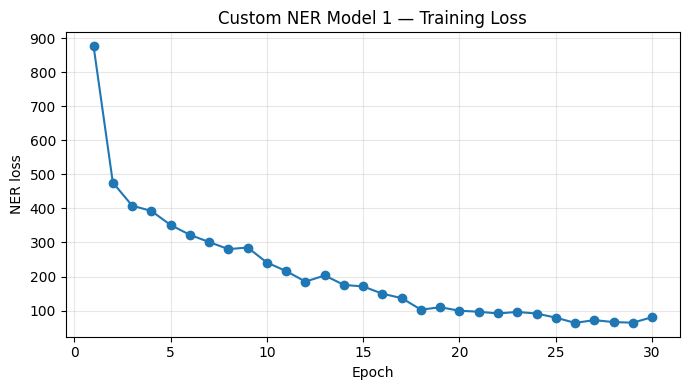

In [19]:
plt.figure(figsize=(7,4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker="o")
plt.xlabel("Epoch"); plt.ylabel("NER loss")
plt.title("Custom NER Model 1 — Training Loss")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

In [21]:
def doc_to_iob(doc):
    tags = ["O"] * len(doc)
    for ent in doc.ents:
        tags[ent.start] = f"B-{ent.label_}"
        for i in range(ent.start + 1, ent.end):
            tags[i] = f"I-{ent.label_}"
    return tags

def aligned_iob(gold_doc, pred_doc):
    """Tokenize pred with the same whitespace as gold for apples-to-apples eval."""
    # Use gold's tokenization (blank spaCy whitespace tokenizer matches input)
    pred = nlp(gold_doc.text)
    return doc_to_iob(gold_doc), doc_to_iob(pred)

In [25]:
#%pip install seqeval

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16252 sha256=a3b8c8e5f51f93ce98bb4341d350e852e8ac712cedfc60454895d6f59e3b4f5c
  Stored in directory: /Users/brandonacosta/Library/Caches/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
Note: you may need to restart the kernel to use updated packages.


In [27]:
from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score as seq_f1

In [29]:
y_true, y_pred = [], []
for gold in test_docs:
    t, p = aligned_iob(gold, None)
    y_true.append(t); y_pred.append(p)

print("Entity-level classification report (seqeval):")
print(seq_report(y_true, y_pred, digits=4))
print(f"Overall entity-level F1: {seq_f1(y_true, y_pred):.4f}")

Entity-level classification report (seqeval):
                 precision    recall  f1-score   support

        Amenity     0.7826    0.6429    0.7059        28
        Cuisine     0.6250    0.7692    0.6897        13
           Dish     0.4000    0.2857    0.3333         7
          Hours     0.0000    0.0000    0.0000         3
       Location     0.6667    0.5833    0.6222        24
          Price     1.0000    0.6667    0.8000         3
         Rating     0.5556    0.7143    0.6250         7
Restaurant_Name     0.4286    0.6000    0.5000        10

      micro avg     0.6196    0.6000    0.6096        95
      macro avg     0.5573    0.5328    0.5345        95
   weighted avg     0.6317    0.6000    0.6081        95

Overall entity-level F1: 0.6096


In [31]:
from seqeval.metrics import precision_score, recall_score

rows = []
for lab in HPARAMS["labels"]:
    # per-entity via seqeval by masking all others to O
    def keep_only(sents, keep):
        return [[t if t.endswith(keep) or t == "O" else "O" for t in s] for s in sents]
    yt = keep_only(y_true, lab)
    yp = keep_only(y_pred, lab)
    rows.append({
        "entity": lab,
        "precision": precision_score(yt, yp),
        "recall":    recall_score(yt, yp),
        "f1":        seq_f1(yt, yp),
    })

per_entity_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
per_entity_df

,entity,precision,recall,f1
0,Price,1.000000,0.666667,0.800000
1,Amenity,0.782609,0.642857,0.705882
2,Cuisine,0.625000,0.769231,0.689655
3,Rating,0.555556,0.714286,0.625000
4,Location,0.666667,0.583333,0.622222
5,Restaurant_Name,0.428571,0.600000,0.500000
6,Dish,0.400000,0.285714,0.333333
7,Hours,0.000000,0.000000,0.000000


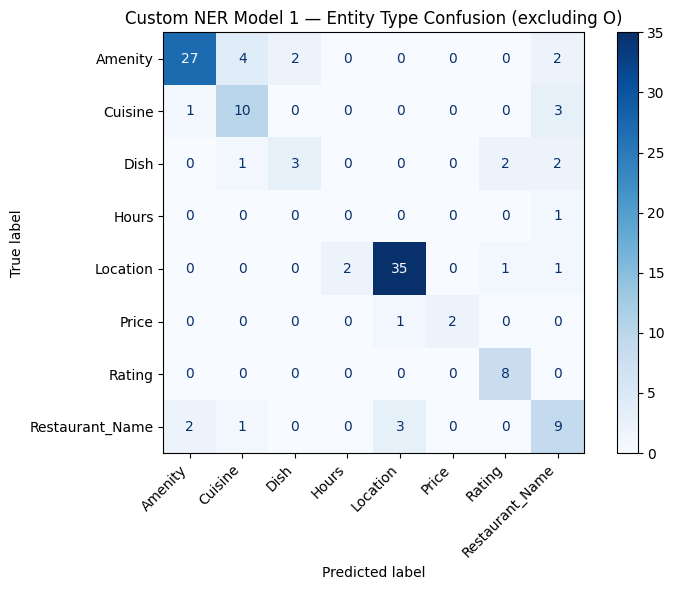

In [33]:
def collapse_bio(tag):
    return tag[2:] if tag.startswith(("B-", "I-")) else tag

y_true_flat = [collapse_bio(t) for sent in y_true for t in sent]
y_pred_flat = [collapse_bio(t) for sent in y_pred for t in sent]
labels_cm   = sorted(set(y_true_flat + y_pred_flat) - {"O"})

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels_cm)
ConfusionMatrixDisplay(cm, display_labels=labels_cm).plot(
    ax=ax, cmap="Blues", values_format="d")
ax.set_title("Custom NER Model 1 — Entity Type Confusion (excluding O)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

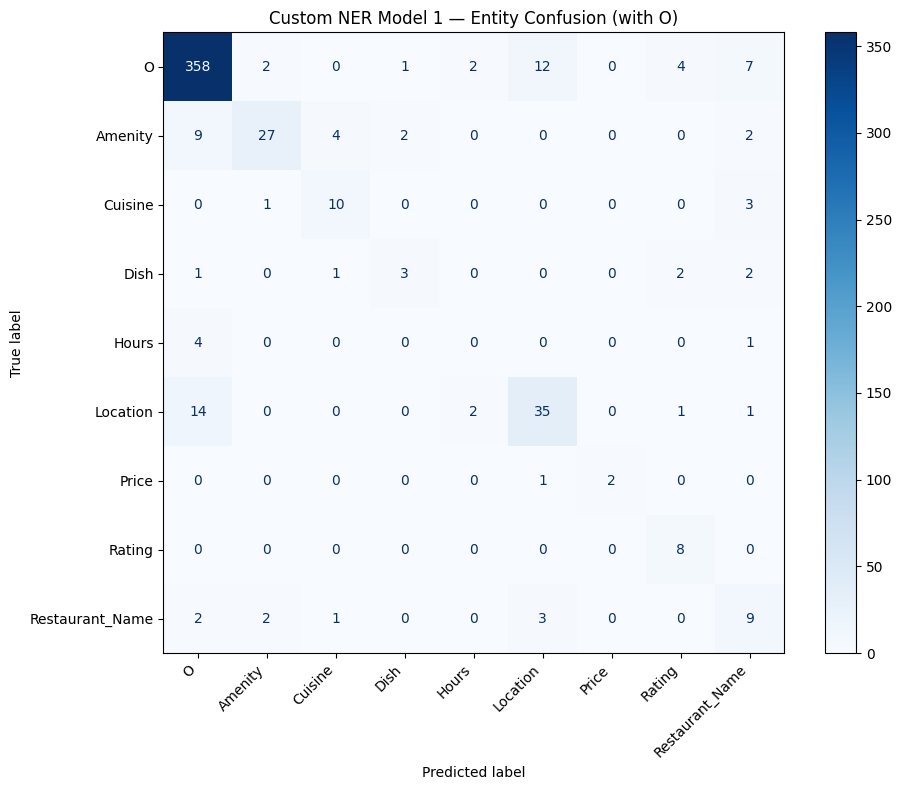

In [35]:
all_labels = ["O"] + labels_cm
fig, ax = plt.subplots(figsize=(10,8))
cm_full = confusion_matrix(y_true_flat, y_pred_flat, labels=all_labels)
ConfusionMatrixDisplay(cm_full, display_labels=all_labels).plot(
    ax=ax, cmap="Blues", values_format="d")
ax.set_title("Custom NER Model 1 — Entity Confusion (with O)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

In [37]:
def classify_errors(y_true_sents, y_pred_sents):
    counts = Counter()
    for yt, yp in zip(y_true_sents, y_pred_sents):
        for a, b in zip(yt, yp):
            if a == b:
                continue
            if a == "O" and b != "O":
                counts["false_positive"] += 1
            elif a != "O" and b == "O":
                counts["false_negative"] += 1
            elif collapse_bio(a) != collapse_bio(b):
                counts["type_mismatch"] += 1
            else:
                counts["boundary_error"] += 1  # same type, different B/I
    return counts

err = classify_errors(y_true, y_pred)
pd.Series(err).rename("count").to_frame()

,count
type_mismatch,29
false_positive,28
false_negative,30
boundary_error,6


## Custom NER Model 1 — summary

- Training docs: 176 | Test docs: 44
- Epochs: 30 | Dropout: 0.35 | Batch compounding: 4 → 32 (×1.001)
- Overall entity-level F1 (seqeval): **0.6096**
- Per-entity F1 leaders/laggards: see `per_entity_df`
- Dominant error category: **FP: 28 / FN: 30 / type: 29 / boundary: 6**
- Weakest entity types: **Restuarant_Name (0.50000), Dish (0.3333), Hours (0.0000)**

# Step 7 — Batch 3 Pre-Annotation Generation (for Human Correction)

Goal: run Model 1 on ~100 unseen docs from `dataset_valid.json` (disjoint from training),
prioritizing candidates likely to contain Dish/Hours (our weakest types).
Export as Label Studio JSON with `predictions` field so reviewers see editable suggestions.

In [65]:
import json, random
from pathlib import Path
import spacy

random.seed(42)

In [67]:
# Option A: re-use `nlp` from the Model 1 notebook (same kernel)
# Option B: load from a saved path — see note at bottom
try:
    nlp
    print("Using in-memory Model 1:", nlp.pipe_names)
except NameError:
    nlp = spacy.load("/path/to/ner_model1_output")  # <- edit if needed
    print("Loaded Model 1 from disk:", nlp.pipe_names)

Using in-memory Model 1: ['ner']


In [69]:
valid_path = Path("../data/raw/dataset_valid.json")  # adjust if you run from a different cwd

candidates = []
with open(valid_path, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)
        text = " ".join(obj["tokens"])
        candidates.append(text)

print("Candidate pool size:", len(candidates))
print("Example:", candidates[0])

Candidate pool size: 760
Example: 2 start restaurants with inside dining


In [71]:
# Light, defensible keyword triggers (lowercase, word-level match)
DISH_TRIGGERS = {
    "burger","burgers","pizza","pasta","taco","tacos","burrito","sushi",
    "sandwich","salad","steak","soup","ramen","noodle","noodles","wings",
    "bbq","barbecue","pancake","pancakes","waffle","waffles","fries",
    "dumpling","dumplings","curry","kebab","fried","grilled","chicken",
    "beef","pork","shrimp","lobster","tofu","dish","dishes","entree",
    "appetizer","dessert","ice cream",
}
HOURS_TRIGGERS = {
    "open","opens","closed","close","closes","hours","24","24/7",
    "late","night","early","morning","afternoon","evening","midnight",
    "noon","breakfast","lunch","brunch","dinner","am","pm","weekend",
    "weekday","weekdays","weekends",
}

def has_trigger(text, triggers):
    toks = text.lower().split()
    return any(t in triggers for t in toks)

prioritized = [t for t in candidates if has_trigger(t, DISH_TRIGGERS | HOURS_TRIGGERS)]
print("Prioritized (Dish or Hours trigger):", len(prioritized))

Prioritized (Dish or Hours trigger): 232


In [73]:
TARGET_SIZE = 100
random.shuffle(prioritized)

batch = prioritized[:TARGET_SIZE]

if len(batch) < TARGET_SIZE:
    remaining = [t for t in candidates if t not in set(batch)]
    random.shuffle(remaining)
    batch += remaining[:TARGET_SIZE - len(batch)]

print("Batch 3 size:", len(batch))
print("Preview:")
for t in batch[:5]: print(" -", t)

Batch 3 size: 100
Preview:
 - at what time does dennys open
 - are there any restaurants nearby that are open late
 - any beef cuisine restaurants with brewpub and great prices
 - are there any waterfront dining spots that is open before 12 a
 - are there any diners open before 5 am that allow smoking


In [75]:
def export_label_studio_json(texts, nlp_model, output_file):
    """
    Pre-annotated tasks with `predictions` field (editable in Label Studio).
    """
    tasks = []
    for text in texts:
        doc = nlp_model(text)
        results = []
        for ent in doc.ents:
            results.append({
                "from_name": "label",
                "to_name": "text",
                "type": "labels",
                "value": {
                    "start": ent.start_char,
                    "end": ent.end_char,
                    "text": ent.text,
                    "labels": [ent.label_],
                },
            })
        tasks.append({
            "data": {"text": text},
            "predictions": [{"result": results}] if results else [],
        })

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(tasks, f, indent=2)
    print(f"Wrote {len(tasks)} tasks to {output_file}")

In [97]:
from pathlib import Path
out_path = "batch3_preannotations.json"   # outside the repo
export_label_studio_json(batch, nlp, str(out_path))

# Quick sanity check
with open(out_path) as f:
    preview = json.load(f)
print("Tasks written:", len(preview))
print("First task preview:")
print(json.dumps(preview[0], indent=2)[:800])

Wrote 100 tasks to batch3_preannotations.json
Tasks written: 100
First task preview:
{
  "data": {
    "text": "at what time does dennys open"
  },
  "predictions": [
    {
      "result": [
        {
          "from_name": "label",
          "to_name": "text",
          "type": "labels",
          "value": {
            "start": 13,
            "end": 24,
            "text": "does dennys",
            "labels": [
              "Restaurant_Name"
            ]
          }
        }
      ]
    }
  ]
}


**Next step (manual):** upload `~/batch3_preannotations.json` into Label Studio,
review + correct predictions (focus on Dish and Hours), then export the corrected
tasks as Label Studio JSON. Save the corrected export as `batch3_corrected.json`
and point Model 2 at it.

# Step 7 — Custom NER Model 2 (Expanded Data + 50 epochs)

Training source: Model 1 training pool + corrected Batch 3 (pre-annotated by Model 1, human-reviewed).
Test set: frozen from Model 1 (same `random_state=42`, same stratify rule).
Labels: Rating, Amenity, Location, Restaurant_Name, Price, Hours, Dish, Cuisine.

In [99]:
import json, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding, filter_spans
from spacy.scorer import Scorer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score as seq_f1
from seqeval.metrics import precision_score as seq_p
from seqeval.metrics import recall_score as seq_r

random.seed(42); np.random.seed(42)

In [86]:
HPARAMS_M2 = {
    "model_base": "blank:en",
    "labels": ["Rating", "Amenity", "Location", "Restaurant_Name",
               "Price", "Hours", "Dish", "Cuisine"],
    "test_size": 0.20,
    "random_state": 42,
    "n_epochs": 50,            # <-- up from 30
    "dropout": 0.35,
    "batch_start": 4.0,
    "batch_stop": 32.0,
    "batch_compound": 1.001,
    "optimizer": "spacy-default (Adam)",
    "extra_training_source": "batch3_corrected.json",
}
HPARAMS_M2

{'model_base': 'blank:en',
 'labels': ['Rating',
  'Amenity',
  'Location',
  'Restaurant_Name',
  'Price',
  'Hours',
  'Dish',
  'Cuisine'],
 'test_size': 0.2,
 'random_state': 42,
 'n_epochs': 50,
 'dropout': 0.35,
 'batch_start': 4.0,
 'batch_stop': 32.0,
 'batch_compound': 1.001,
 'optimizer': 'spacy-default (Adam)',
 'extra_training_source': 'batch3_corrected.json'}

In [101]:
def pick_gold_annotation(task):
    anns = task.get("annotations", [])
    if not anns: return None
    for a in anns:
        if a.get("state") == "ACCEPTED" or a.get("reviews"):
            return a
    return anns[0]

def ls_task_to_spans(task):
    ann = pick_gold_annotation(task)
    if ann is None: return None
    text = task["data"]["text"]
    ents = []
    for r in ann.get("result", []):
        if r.get("type") != "labels": continue
        v = r["value"]
        if v.get("labels"):
            ents.append((v["start"], v["end"], v["labels"][0]))
    return text, ents

with open("220_docs_with_overlap.json", "r", encoding="utf-8") as f:
    tasks = json.load(f)

base_raw = [x for x in (ls_task_to_spans(t) for t in tasks) if x is not None]
print("Base pool (Model 1 source):", len(base_raw))

Base pool (Model 1 source): 220


In [103]:
# Path where YOU saved the corrected export from Label Studio.
BATCH3_PATH = "batch3_corrected.json"

with open(BATCH3_PATH, "r", encoding="utf-8") as f:
    batch3_tasks = json.load(f)

batch3_raw = [x for x in (ls_task_to_spans(t) for t in batch3_tasks) if x is not None]
print("Batch 3 corrected docs:", len(batch3_raw))

Batch 3 corrected docs: 100


In [105]:
nlp_blank = spacy.blank("en")

def to_spacy_doc(text, ents):
    doc = nlp_blank.make_doc(text)
    spans = []
    for start, end, label in ents:
        s = doc.char_span(start, end, label=label, alignment_mode="contract")
        if s is not None: spans.append(s)
    doc.ents = filter_spans(spans)
    return doc

base_docs   = [to_spacy_doc(t, e) for t, e in base_raw]
batch3_docs = [to_spacy_doc(t, e) for t, e in batch3_raw]
print("Base docs:", len(base_docs), "| Batch 3 docs:", len(batch3_docs))

Base docs: 220 | Batch 3 docs: 100


In [107]:
label_priority = {lab: i for i, lab in enumerate(
    ["Hours","Price","Rating","Dish","Cuisine",
     "Restaurant_Name","Amenity","Location"]
)}

def rarest_label(doc):
    labs = [e.label_ for e in doc.ents]
    return sorted(labs, key=lambda x: label_priority.get(x, 99))[0] if labs else "NONE"

strata = [rarest_label(d) for d in base_docs]
sc = Counter(strata)
safe_strata = [s if sc[s] >= 2 else "NONE" for s in strata]

train_docs_m1, test_docs_m1 = train_test_split(
    base_docs,
    test_size=HPARAMS_M2["test_size"],
    random_state=HPARAMS_M2["random_state"],
    stratify=safe_strata,
)
print(f"Model 1 split recreated -> train: {len(train_docs_m1)} | test (FROZEN): {len(test_docs_m1)}")

Model 1 split recreated -> train: 176 | test (FROZEN): 44


In [109]:
train_docs_m2 = train_docs_m1 + batch3_docs
test_docs_m2  = test_docs_m1        # UNCHANGED

print(f"Model 2 train: {len(train_docs_m2)} | test (frozen): {len(test_docs_m2)}")

Model 2 train: 276 | test (frozen): 44


In [113]:
nlp2 = spacy.blank("en")
ner2 = nlp2.add_pipe("ner")
for lab in HPARAMS_M2["labels"]:
    ner2.add_label(lab)
print("Model 2 pipe:", nlp2.pipe_names, "| labels:", ner2.labels)

Model 2 pipe: ['ner'] | labels: ('Amenity', 'Cuisine', 'Dish', 'Hours', 'Location', 'Price', 'Rating', 'Restaurant_Name')


In [115]:
optimizer = nlp2.initialize(
    lambda: [Example(nlp2.make_doc(d.text), d) for d in train_docs_m2]
)

loss_history_m2 = []
for epoch in range(HPARAMS_M2["n_epochs"]):
    random.shuffle(train_docs_m2)
    losses = {}
    batches = minibatch(
        train_docs_m2,
        size=compounding(HPARAMS_M2["batch_start"],
                         HPARAMS_M2["batch_stop"],
                         HPARAMS_M2["batch_compound"]),
    )
    for batch in batches:
        examples = [Example(nlp2.make_doc(d.text), d) for d in batch]
        nlp2.update(examples, drop=HPARAMS_M2["dropout"], losses=losses, sgd=optimizer)
    loss_history_m2.append(losses.get("ner", 0.0))
    print(f"Epoch {epoch+1:02d} | NER loss: {losses.get('ner', 0.0):.3f}")

Epoch 01 | NER loss: 1268.854
Epoch 02 | NER loss: 752.831
Epoch 03 | NER loss: 732.913
Epoch 04 | NER loss: 604.798
Epoch 05 | NER loss: 533.121
Epoch 06 | NER loss: 456.734
Epoch 07 | NER loss: 461.079
Epoch 08 | NER loss: 398.954
Epoch 09 | NER loss: 345.888
Epoch 10 | NER loss: 315.028
Epoch 11 | NER loss: 305.707
Epoch 12 | NER loss: 302.304
Epoch 13 | NER loss: 263.866
Epoch 14 | NER loss: 242.379
Epoch 15 | NER loss: 241.673
Epoch 16 | NER loss: 190.673
Epoch 17 | NER loss: 210.358
Epoch 18 | NER loss: 180.486
Epoch 19 | NER loss: 189.951
Epoch 20 | NER loss: 165.813
Epoch 21 | NER loss: 141.884
Epoch 22 | NER loss: 129.384
Epoch 23 | NER loss: 144.005
Epoch 24 | NER loss: 121.080
Epoch 25 | NER loss: 129.879
Epoch 26 | NER loss: 151.020
Epoch 27 | NER loss: 137.539
Epoch 28 | NER loss: 131.728
Epoch 29 | NER loss: 124.978
Epoch 30 | NER loss: 104.235
Epoch 31 | NER loss: 143.460
Epoch 32 | NER loss: 91.780
Epoch 33 | NER loss: 104.155
Epoch 34 | NER loss: 75.355
Epoch 35 | NER 

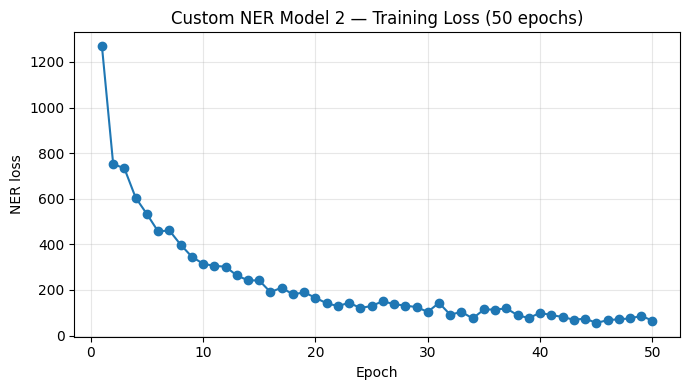

In [116]:
plt.figure(figsize=(7,4))
plt.plot(range(1, len(loss_history_m2)+1), loss_history_m2, marker="o")
plt.xlabel("Epoch"); plt.ylabel("NER loss")
plt.title("Custom NER Model 2 — Training Loss (50 epochs)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [117]:
def doc_to_iob(doc):
    tags = ["O"] * len(doc)
    for ent in doc.ents:
        tags[ent.start] = f"B-{ent.label_}"
        for i in range(ent.start + 1, ent.end):
            tags[i] = f"I-{ent.label_}"
    return tags

def eval_with_seqeval(model, test_docs):
    y_true, y_pred = [], []
    for gold in test_docs:
        pred = model(gold.text)
        y_true.append(doc_to_iob(gold))
        y_pred.append(doc_to_iob(pred))
    return y_true, y_pred

y_true_m2, y_pred_m2 = eval_with_seqeval(nlp2, test_docs_m2)

print("Model 2 — seqeval (entity-level) on FROZEN test set:")
print(seq_report(y_true_m2, y_pred_m2, digits=4))
print(f"Model 2 overall F1: {seq_f1(y_true_m2, y_pred_m2):.4f}")

Model 2 — seqeval (entity-level) on FROZEN test set:
                 precision    recall  f1-score   support

        Amenity     0.7308    0.6786    0.7037        28
        Cuisine     0.8462    0.8462    0.8462        13
           Dish     1.0000    0.2857    0.4444         7
          Hours     0.0000    0.0000    0.0000         3
       Location     0.7083    0.7083    0.7083        24
          Price     1.0000    0.6667    0.8000         3
         Rating     0.7143    0.7143    0.7143         7
Restaurant_Name     0.4667    0.7000    0.5600        10

      micro avg     0.7000    0.6632    0.6811        95
      macro avg     0.6833    0.5750    0.5971        95
   weighted avg     0.7171    0.6632    0.6717        95

Model 2 overall F1: 0.6811


In [118]:
def score_with_spacy(model, test_docs):
    exs = []
    for gold in test_docs:
        pred = model(gold.text)
        ex = Example(pred, gold)
        exs.append(ex)
    return Scorer().score(exs)

scores_m2 = score_with_spacy(nlp2, test_docs_m2)
print("Model 2 (Scorer) -- P: {:.4f} | R: {:.4f} | F1: {:.4f}".format(
    scores_m2["ents_p"], scores_m2["ents_r"], scores_m2["ents_f"]))

pd.DataFrame([
    {"Entity": lab, "Precision": round(v["p"],4), "Recall": round(v["r"],4), "F1": round(v["f"],4)}
    for lab, v in scores_m2["ents_per_type"].items()
]).sort_values("F1", ascending=False).reset_index(drop=True)

Model 2 (Scorer) -- P: 0.7000 | R: 0.6632 | F1: 0.6811


,Entity,Precision,Recall,F1
0,Cuisine,0.8462,0.8462,0.8462
1,Price,1.0000,0.6667,0.8000
2,Rating,0.7143,0.7143,0.7143
3,Location,0.7083,0.7083,0.7083
4,Amenity,0.7308,0.6786,0.7037
5,Restaurant_Name,0.4667,0.7000,0.5600
6,Dish,1.0000,0.2857,0.4444
7,Hours,0.0000,0.0000,0.0000


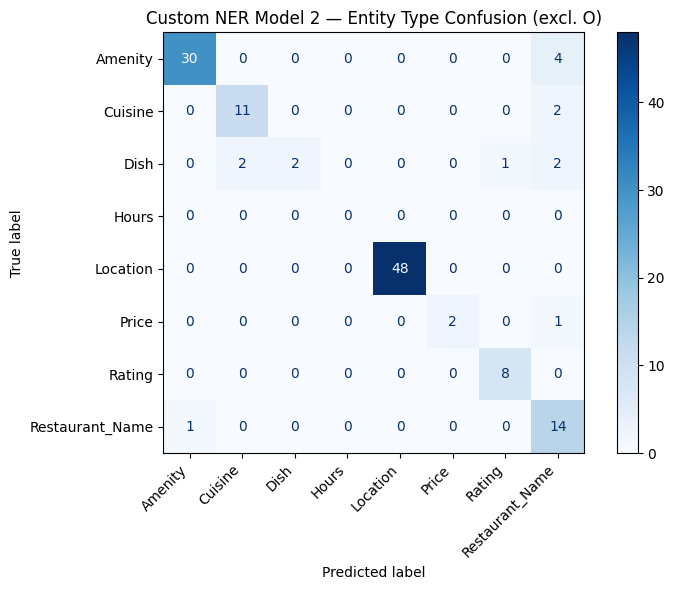

In [119]:
def collapse_bio(t): return t[2:] if t.startswith(("B-","I-")) else t

yt = [collapse_bio(t) for s in y_true_m2 for t in s]
yp = [collapse_bio(t) for s in y_pred_m2 for t in s]
labels_cm = sorted(set(yt + yp) - {"O"})

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(yt, yp, labels=labels_cm)
ConfusionMatrixDisplay(cm, display_labels=labels_cm).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Custom NER Model 2 — Entity Type Confusion (excl. O)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

In [120]:
def classify_errors(y_true_s, y_pred_s):
    c = Counter()
    for yt, yp in zip(y_true_s, y_pred_s):
        for a, b in zip(yt, yp):
            if a == b: continue
            if a == "O" and b != "O": c["false_positive"] += 1
            elif a != "O" and b == "O": c["false_negative"] += 1
            elif collapse_bio(a) != collapse_bio(b): c["type_mismatch"] += 1
            else: c["boundary_error"] += 1
    return c

err_m2 = classify_errors(y_true_m2, y_pred_m2)
pd.Series(err_m2, name="count").to_frame()

,count
type_mismatch,13
false_positive,16
false_negative,25
boundary_error,8
